Original Dataset can be found here:
https://www.kaggle.com/datasets/suchintikasarkar/sentiment-analysis-for-mental-health

In [59]:
# Library Imports

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
import seaborn as sns
import xgboost
import joblib # For app creation

import re
import string
import random
from imblearn.over_sampling import SMOTE, RandomOverSampler
from imblearn.pipeline import Pipeline

from sklearn.model_selection import GridSearchCV, StratifiedKFold
from scipy.sparse import hstack 
from wordcloud import WordCloud

import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import PorterStemmer, SnowballStemmer
from nltk.stem import WordNetLemmatizer
from nltk.corpus import wordnet

from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, precision_recall_fscore_support

from sklearn.linear_model import LogisticRegression # Linear Model
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier   # XGBoost Decision Tree
from sklearn.naive_bayes import ComplementNB    # Probabilistic Classifier
from sklearn.naive_bayes import MultinomialNB

import warnings
warnings.filterwarnings("ignore")

Loading Data

In [60]:
df = pd.read_csv('dataset.csv', index_col=0)

df1 = df.copy() 
df1.dropna(inplace = True)
df1.head() 

,statement,status
0,oh my gosh,Anxiety
1,"trouble sleeping, confused mind, restless hear...",Anxiety
2,"All wrong, back off dear, forward doubt. Stay ...",Anxiety
3,I've shifted my focus to something else but I'...,Anxiety
4,"I'm restless and restless, it's been a month n...",Anxiety


In [61]:
df1.shape

(52680, 2)

In [62]:
df1["status"].unique()

<StringArray>
[             'Anxiety',               'Normal',           'Depression',
             'Suicidal',               'Stress',              'Bipolar',
 'Personality disorder']
Length: 7, dtype: str

In [63]:
# Convert the labels (Change any disturbed status, like depression, anxiety, etc. to "Disturbed")
df1["binary_label"] = df1["status"].apply(
    lambda label: "Normal"
    if str(label).strip().lower() == "normal"
    else "Disturbed"
)

In [64]:
df1["binary_label"].unique()

<StringArray>
['Disturbed', 'Normal']
Length: 2, dtype: str

In [65]:
# Drop old column and set new label to "status"
df1 = df1.drop(columns=["status"]).rename(
    columns={"binary_label": "status"}
)

In [66]:
print(df1["status"].value_counts())

status
Disturbed    36337
Normal       16343
Name: count, dtype: int64


In [67]:
df1.shape

(52680, 2)

In [68]:
# Check length of statement
df1['statement_len'] = df1['statement'].apply(lambda x: len(x.split(' ')))
df1.head() 

,statement,status,statement_len
0,oh my gosh,Disturbed,3
1,"trouble sleeping, confused mind, restless hear...",Disturbed,10
2,"All wrong, back off dear, forward doubt. Stay ...",Disturbed,14
3,I've shifted my focus to something else but I'...,Disturbed,11
4,"I'm restless and restless, it's been a month n...",Disturbed,14


In [69]:
print(df1.info())

<class 'pandas.DataFrame'>
Index: 52680 entries, 0 to 53042
Data columns (total 3 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   statement      52680 non-null  str  
 1   status         52680 non-null  str  
 2   statement_len  52680 non-null  int64
dtypes: int64(1), str(2)
memory usage: 1.6+ MB
None


In [70]:
df1.describe(include='object').T

,count,unique,top,freq
statement,52680,51068,what do you mean?,22
status,52680,2,Disturbed,36337


Exploratory Data Analysis

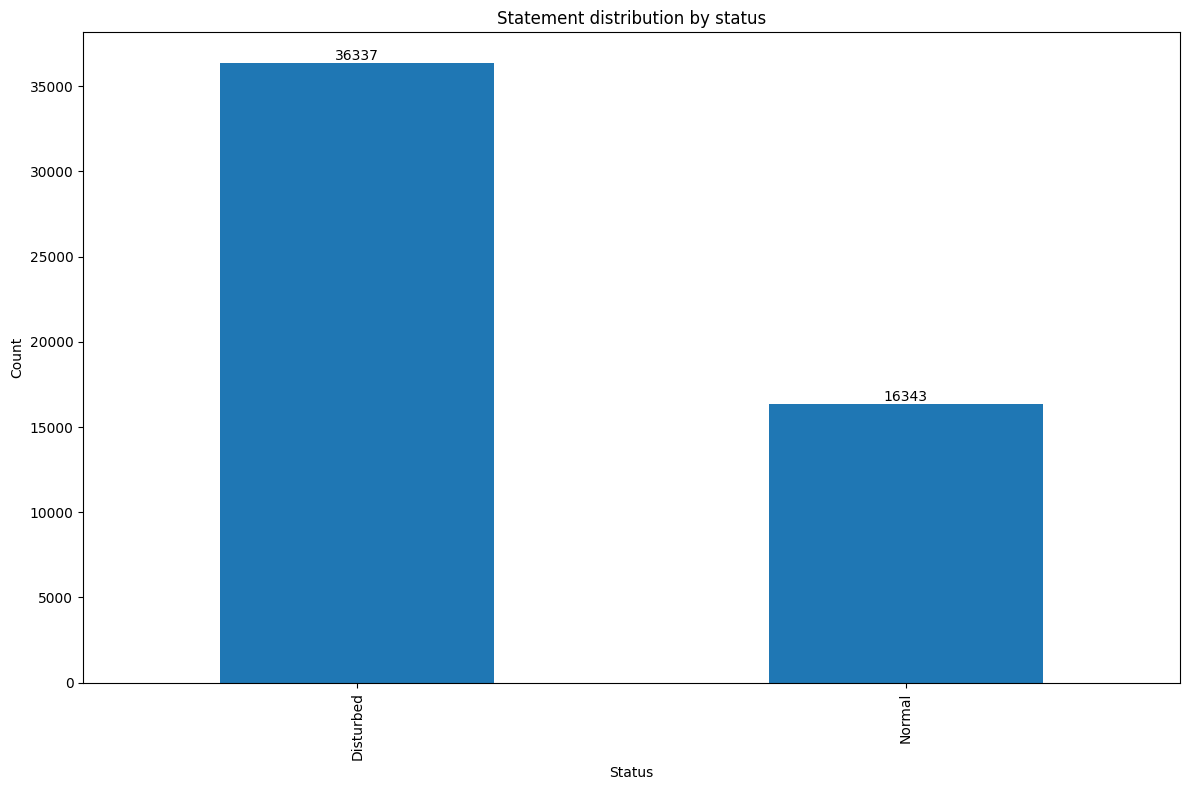

In [71]:
# Explore target distribution

plt.figure(figsize=(12,8))

# get the unique status values and their counts
status_counts = df1['status'].value_counts()

# create the bar plot
ax = status_counts.plot(kind='bar')

# add the count labels on top of each bar
for i, v in enumerate(status_counts):
    ax.text(i, v, str(v), ha='center', va='bottom')

plt.title('Statement distribution by status')
plt.xlabel('Status')
plt.ylabel('Count')
plt.tight_layout()
plt.show() 

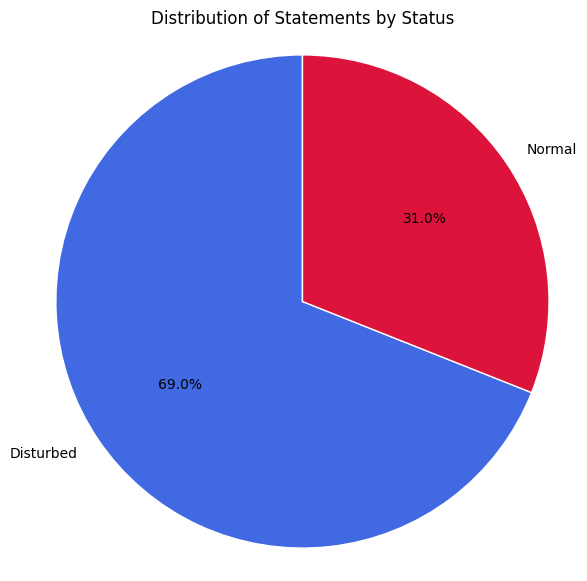

In [72]:
import matplotlib.pyplot as plt

class_counts = df1["status"].value_counts()

plt.figure(figsize=(7, 7))

plt.pie(
    class_counts.values,
    labels=class_counts.index,
    autopct="%1.1f%%",
    startangle=90,
    colors=["royalblue", "crimson"],
    wedgeprops={"edgecolor": "white"}
)

plt.title("Distribution of Statements by Status")
plt.axis("equal")
plt.show()

In [73]:
df1["statement_len"].describe()

count    52680.000000
mean       112.915395
std        161.267713
min          1.000000
25%         15.000000
50%         62.000000
75%        148.000000
max       5419.000000
Name: statement_len, dtype: float64

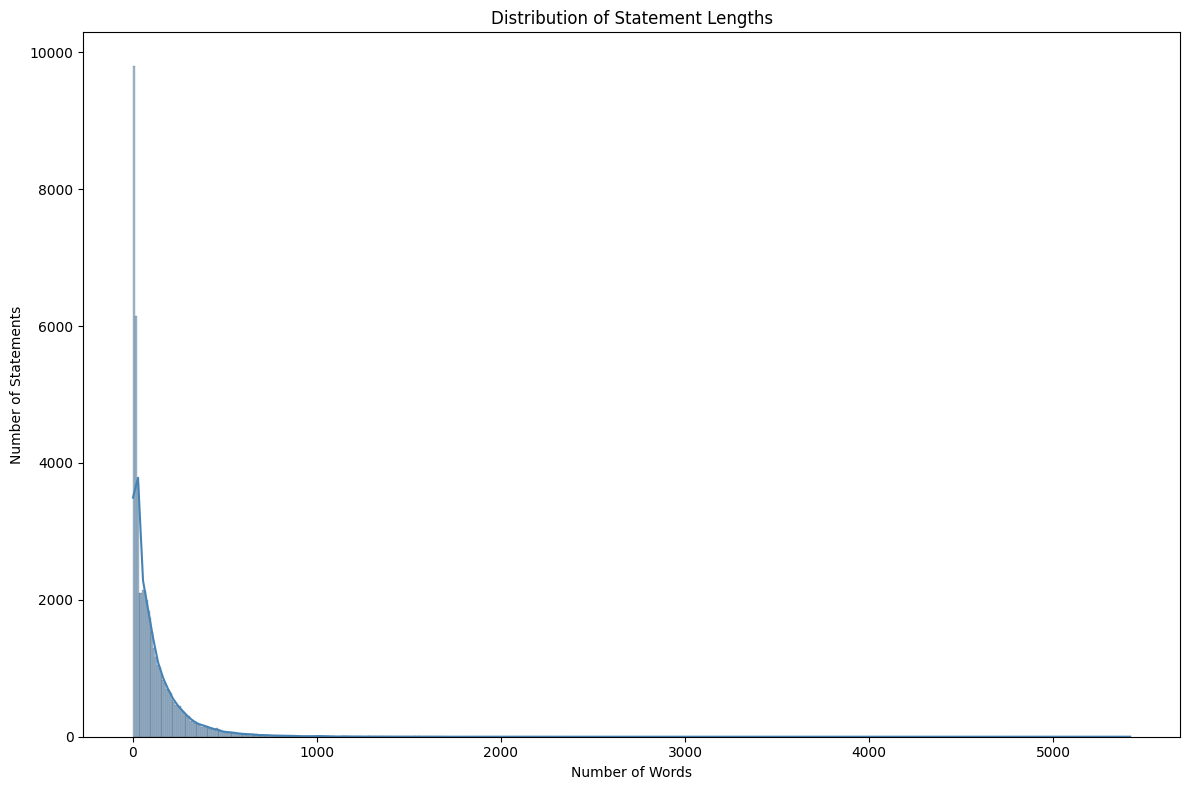

In [74]:
# Histogram of statement lengths of classes
plt.figure(figsize=(12, 8))

sns.histplot(
    data=df1,
    x="statement_len",
    binwidth=10,
    kde=True,
    color="steelblue"
)


plt.title("Distribution of Statement Lengths")
plt.xlabel("Number of Words")
plt.ylabel("Number of Statements")
plt.tight_layout()
plt.show()

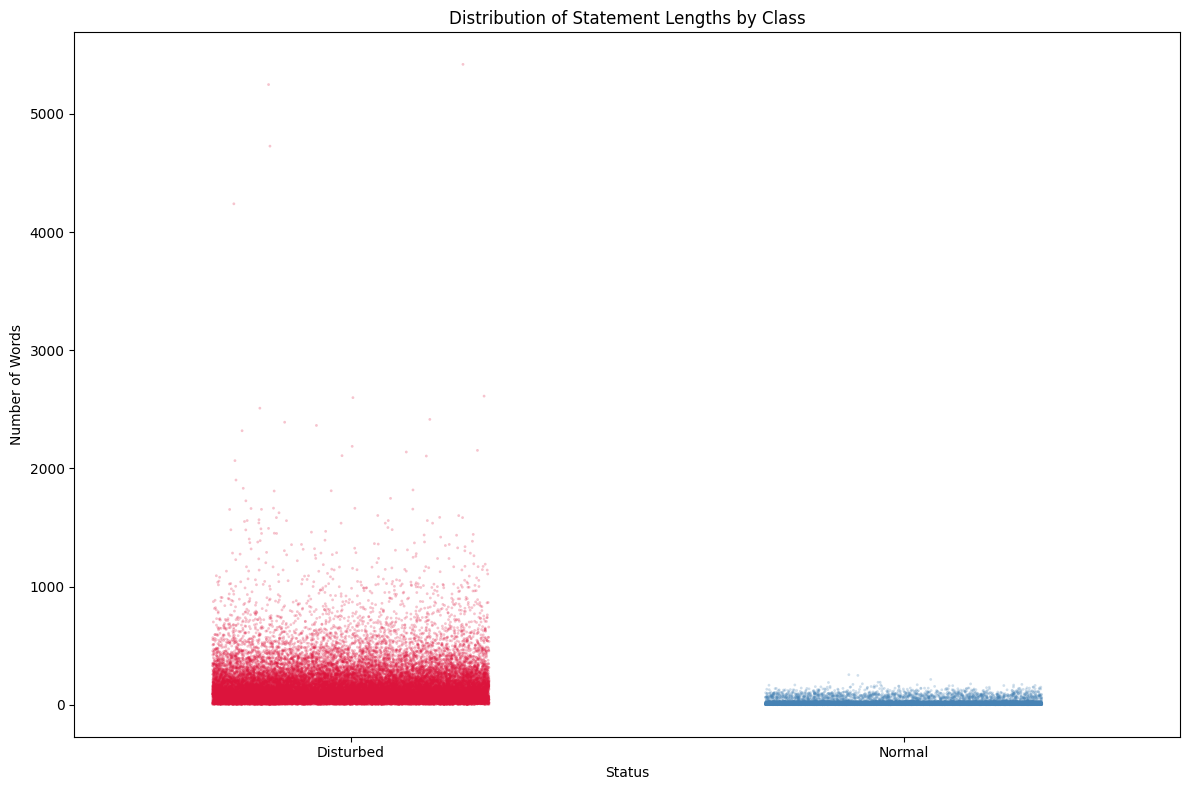

In [75]:
# Jittered Strip Plot to show statement lengths

plt.figure(figsize=(12, 8))

sns.stripplot(
    data=df1,
    x="status",
    y="statement_len",
    hue="status",
    palette={
        "Normal": "steelblue",
        "Disturbed": "crimson"
    },
    jitter=0.25,
    alpha=0.25,
    size=2,
    legend=False
)

plt.title("Distribution of Statement Lengths by Class")
plt.xlabel("Status")
plt.ylabel("Number of Words")
plt.tight_layout()
plt.show()

In [76]:
# Check long statements
long_statements = df1[df1["statement_len"] > 4000]

long_statements

,statement,status,statement_len
10834,I have only 1 person I can somewhat open to bu...,Disturbed,5248
39752,it doesn t matter anymore i m going to copy an...,Disturbed,4239
46660,DEPRESSION HAS A PURPOSE: HOW TO USE IT RIGHT ...,Disturbed,4727
51396,Please help me understand what I went through ...,Disturbed,5419


Data Splitting


In [77]:
# Create another data frame, this is to be used from here on out
df2 = df1.copy()

In [78]:
# define x and y
x = df2['statement']
y = df2['status']

print(len(x), len(y)) 

52680 52680


In [79]:
# Split into train and test sets

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=42, stratify=y)
print(len(x_train), len(y_train))
print(len(x_test), len(y_test))  

36876 36876
15804 15804


In [80]:
# Combine into training data for pre-preprocessing

training_data = pd.DataFrame({
    "statement": x_train.reset_index(drop=True),
    "status": pd.Series(y_train).reset_index(drop=True)
})

training_data.head()

,statement,status
0,why don't you wash it?,Normal
1,"The task at the site has to be settled, the me...",Normal
2,Hello.I want to make this post short and direc...,Disturbed
3,"Hey redditors, idk where to post this so I am ...",Disturbed
4,lawl my fav icon is back hahahahawjkapajaahwj. ️,Normal



Data Pre-processing

In [81]:
# Cleaning the corpus

def clean_text(text):
    
    # Convert to string and lowercase
    text = str(text).lower()

    # Removal of unnecessary text
    text = re.sub(r'\[.*?\]', '', text)
    text = re.sub(r'https?://\S+|www\.\S+|\[.*?\]\(.*?\)', '', text) # URL and links
    text = re.sub(r'<.*?>+', '', text) # HTML tags
    text = re.sub(r'@\w+', '', text) # Handles (Text that starts with @)
    text = re.sub(f'[{re.escape(string.punctuation)}]', '', text) # Punctuation and special characters
    text = re.sub(r'\n', ' ', text) # newlines
    text = re.sub(r'\w*\d\w*', '', text) # Words containing numbers
    text = re.sub(r'\s+', ' ', text) # Extra spaces
    
    return text.strip()

In [82]:
nltk.download('stopwords') # Install stopwords

stop_words = stopwords.words('english') 
more_stopwords = {"u", "im", "c"}

stop_words = set(stop_words)
stop_words.update(more_stopwords)

# Preserve negation words
stop_words = stop_words - {
    "no",
    "not",
    "nor",
    "never"
}

# Method to remove stopwords
def remove_stopwords(text):
    text = ' '.join(word for word in text.split(' ') if word not in stop_words)
    return text


[nltk_data] Downloading package stopwords to C:\Users\ASFAR NIBURAS
[nltk_data]     KHAN\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [83]:
# Stemming (Suggested to be used for simplicity)

stemmer = nltk.SnowballStemmer("english")

def stemm_text(text):
    text = ' '.join(stemmer.stem(word) for word in text.split(' '))
    return text


In [84]:
# Preprocessing function
def preprocess_data(text):
    #Clean puntuation, urls, and so on
    text = clean_text(text)

    # Remove stopwords
    text = remove_stopwords(text)

    # Stemm text
    text = stemm_text(text)
    
    return text 

In [85]:
# Pre-process only the training dataset

training_data['statement_clean'] = training_data['statement'].apply(preprocess_data)
training_data.head()

,statement,status,statement_clean
0,why don't you wash it?,Normal,dont wash
1,"The task at the site has to be settled, the me...",Normal,task site settl meet attend back back sometim ...
2,Hello.I want to make this post short and direc...,Disturbed,helloi want make post short direct would like ...
3,"Hey redditors, idk where to post this so I am ...",Disturbed,hey redditor idk post tire diagnos thing never...
4,lawl my fav icon is back hahahahawjkapajaahwj. ️,Normal,lawl fav icon back hahahahawjkapajaahwj ️


In [86]:
# Encode label
l_encoder = LabelEncoder()

l_encoder.fit(training_data['status'])

training_data['status_encoded'] = l_encoder.transform(training_data['status']) 
training_data.head() 

,statement,status,statement_clean,status_encoded
0,why don't you wash it?,Normal,dont wash,1
1,"The task at the site has to be settled, the me...",Normal,task site settl meet attend back back sometim ...,1
2,Hello.I want to make this post short and direc...,Disturbed,helloi want make post short direct would like ...,0
3,"Hey redditors, idk where to post this so I am ...",Disturbed,hey redditor idk post tire diagnos thing never...,0
4,lawl my fav icon is back hahahahawjkapajaahwj. ️,Normal,lawl fav icon back hahahahawjkapajaahwj ️,1


In [87]:
# Split training data again

x_train = training_data['statement_clean']
y_train = training_data['status_encoded']

Tokenization (For visuals)

In [88]:
nltk.download('punkt')
nltk.download('punkt_tab')
from nltk.tokenize import word_tokenize

[nltk_data] Downloading package punkt to C:\Users\ASFAR NIBURAS
[nltk_data]     KHAN\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to C:\Users\ASFAR NIBURAS
[nltk_data]     KHAN\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


In [89]:
training_data['tokens'] = training_data['statement_clean'].apply(word_tokenize)
training_data.head()

,statement,status,statement_clean,status_encoded,tokens
0,why don't you wash it?,Normal,dont wash,1,"[dont, wash]"
1,"The task at the site has to be settled, the me...",Normal,task site settl meet attend back back sometim ...,1,"[task, site, settl, meet, attend, back, back, ..."
2,Hello.I want to make this post short and direc...,Disturbed,helloi want make post short direct would like ...,0,"[helloi, want, make, post, short, direct, woul..."
3,"Hey redditors, idk where to post this so I am ...",Disturbed,hey redditor idk post tire diagnos thing never...,0,"[hey, redditor, idk, post, tire, diagnos, thin..."
4,lawl my fav icon is back hahahahawjkapajaahwj. ️,Normal,lawl fav icon back hahahahawjkapajaahwj ️,1,"[lawl, fav, icon, back, hahahahawjkapajaahwj, ️]"


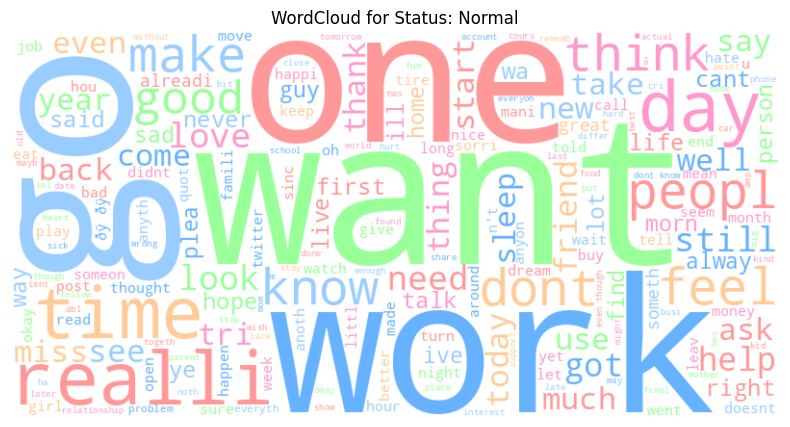

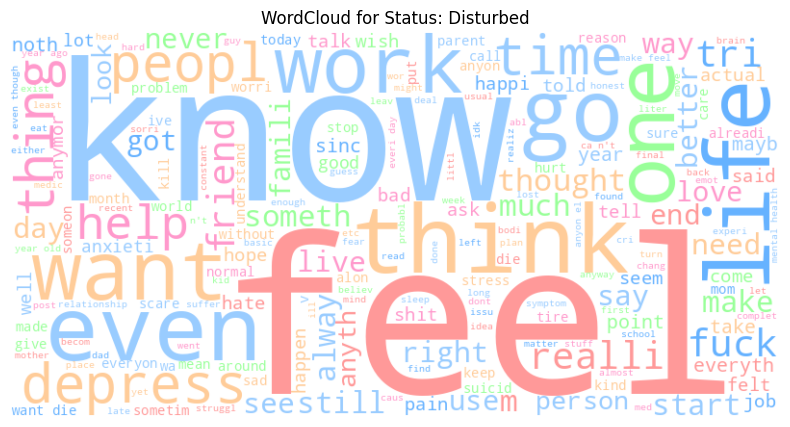

In [90]:
# Get unique categories in 'status'
statuses = training_data['status'].unique()

# Define a list of colors
colors = ['#FF9999', '#66B2FF', '#99FF99', '#FFCC99', '#FF99CC', '#99CCFF']

# Define a color function
def color_func(word, font_size, position, orientation, random_state=101, **kwargs):
    return random.choice(colors)

# Generate and plot the WordCloud for each category
for status in statuses:
    # Filter the tokens data for the current status
    tokens_data = ' '.join(training_data[training_data['status'] == status]['tokens'].dropna().apply(lambda x: ' '.join(x)).tolist())

    # Generate the WordCloud
    wordcloud = WordCloud(width=800, height=400, background_color='white', color_func=color_func).generate(tokens_data)
    
    # Plot the WordCloud
    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')  # Turn off axis
    plt.title(f'WordCloud for Status: {status}')
    plt.show()

Pre-process testing data

In [91]:
# Combine into testing data for pre-preprocessing

testing_data = pd.DataFrame({
    "statement": x_test.reset_index(drop=True),
    "status": pd.Series(y_test).reset_index(drop=True)
})

testing_data.head()

,statement,status
0,Its been this way for three... fucking... year...,Disturbed
1,"Regret of people playing stocks/crypto “yes, I...",Normal
2,can t sleep i don t like sonny being gone,Normal
3,What's your go-to comfort show when you're dow...,Disturbed
4,"does not matter why, just needed to tell someo...",Disturbed


In [92]:
# Preprocess testing data

testing_data['statement_clean'] = testing_data['statement'].apply(preprocess_data)
testing_data['status_encoded'] = l_encoder.transform(testing_data['status']) # Use the same encoder

testing_data.head()

,statement,status,statement_clean,status_encoded
0,Its been this way for three... fucking... year...,Disturbed,way three fuck year not seen anyon outsid scho...,0
1,"Regret of people playing stocks/crypto “yes, I...",Normal,regret peopl play stockscrypto “ye bought earl...,1
2,can t sleep i don t like sonny being gone,Normal,sleep like sonni gone,1
3,What's your go-to comfort show when you're dow...,Disturbed,what goto comfort show your what show your par...,0
4,"does not matter why, just needed to tell someo...",Disturbed,not matter need tell someon part overcom thank...,0


In [93]:
# Split testing data again

x_test = testing_data['statement_clean']
y_test = testing_data['status_encoded']

In [94]:
print(len(x_test), len(y_test)) 

15804 15804


Vectorization

In [ ]:
# instantiate the vectorizer
c_vectorizer = CountVectorizer(stop_words=None, ngram_range=(1,2), max_df=0.7, max_features=50_000)
c_vectorizer.fit(x_train) 

,"input input: {'filename', 'file', 'content'}, default='content'- If `'filename'`, the sequence passed as an argument to fit is expected to be a list of filenames that need reading to fetch the raw content to analyze.- If `'file'`, the sequence items must have a 'read' method (file-like object) that is called to fetch the bytes in memory.- If `'content'`, the input is expected to be a sequence of items that can be of type string or byte.",'content'
,"encoding encoding: str, default='utf-8'If bytes or files are given to analyze, this encoding is used todecode.",'utf-8'
,"decode_error decode_error: {'strict', 'ignore', 'replace'}, default='strict'Instruction on what to do if a byte sequence is given to analyze thatcontains characters not of the given `encoding`. By default, it is'strict', meaning that a UnicodeDecodeError will be raised. Othervalues are 'ignore' and 'replace'.",'strict'
,"strip_accents strip_accents: {'ascii', 'unicode'} or callable, default=NoneRemove accents and perform other character normalizationduring the preprocessing step.'ascii' is a fast method that only works on characters that havea direct ASCII mapping.'unicode' is a slightly slower method that works on any characters.None (default) means no character normalization is performed.Both 'ascii' and 'unicode' use NFKD normalization from:func:`unicodedata.normalize`.",None
,"lowercase lowercase: bool, default=TrueConvert all characters to lowercase before tokenizing.",True
,"preprocessor preprocessor: callable, default=NoneOverride the preprocessing (strip_accents and lowercase) stage whilepreserving the tokenizing and n-grams generation steps.Only applies if ``analyzer`` is not callable.",None
,"tokenizer tokenizer: callable, default=NoneOverride the string tokenization step while preserving thepreprocessing and n-grams generation steps.Only applies if ``analyzer == 'word'``.",None
,"stop_words stop_words: {'english'}, list, default=NoneIf 'english', a built-in stop word list for English is used.There are several known issues with 'english' and you shouldconsider an alternative (see :ref:`stop_words`).If a list, that list is assumed to contain stop words, all of whichwill be removed from the resulting tokens.Only applies if ``analyzer == 'word'``.If None, no stop words will be used. In this case, setting `max_df`to a higher value, such as in the range (0.7, 1.0), can automatically detectand filter stop words based on intra corpus document frequency of terms.",None
,"token_pattern token_pattern: str or None, default=r""(?u)\\b\\w\\w+\\b""Regular expression denoting what constitutes a ""token"", only usedif ``analyzer == 'word'``. The default regexp select tokens of 2or more alphanumeric characters (punctuation is completely ignoredand always treated as a token separator).If there is a capturing group in token_pattern then thecaptured group content, not the entire match, becomes the token.At most one capturing group is permitted.",'(?u)\\b\\w\\w+\\b'
,"ngram_range ngram_range: tuple (min_n, max_n), default=(1, 1)The lower and upper boundary of the range of n-values for differentword n-grams or char n-grams to be extracted. All values of n suchsuch that min_n <= n <= max_n will be used. For example an``ngram_range`` of ``(1, 1)`` means only unigrams, ``(1, 2)`` meansunigrams and bigrams, and ``(2, 2)`` means only bigrams.Only applies if ``analyzer`` is not callable.","(2, ...)"
,"analyzer analyzer: {'word', 'char', 'char_wb'} or callable, default='word'Whether the feature should be made of word n-gram or charactern-grams.Option 'char_wb' creates character n-grams only from text insideword boundaries; n-grams at the edges of words are padded with space.If a callable is passed it is used to extract the sequence of featuresout of the raw, unprocessed input... versionchanged:: 0.21Since v0.21, if ``input`` is ``filename`` or ``file``, the data isfirst read from the file and then passed to the given callableanalyzer.",'word'


In [98]:
# Use the trained to create a document-term matrix from train and test sets
X_train_dtm = c_vectorizer.transform(x_train)
X_test_dtm = c_vectorizer.transform(x_test) 

In [99]:
# Handling Class Imbalance with oversampler

r_oversampler = RandomOverSampler(random_state= 42) 
x_train_resampled, y_train_resampled = r_oversampler.fit_resample(X_train_dtm, y_train) 
print((x_train_resampled.shape), (y_train_resampled.shape))

# Oversampler and vectorizer is used here for visuals, the same oversampler and vectorizer will be used in the GridCV pipelines

(50872, 50000) (50872,)


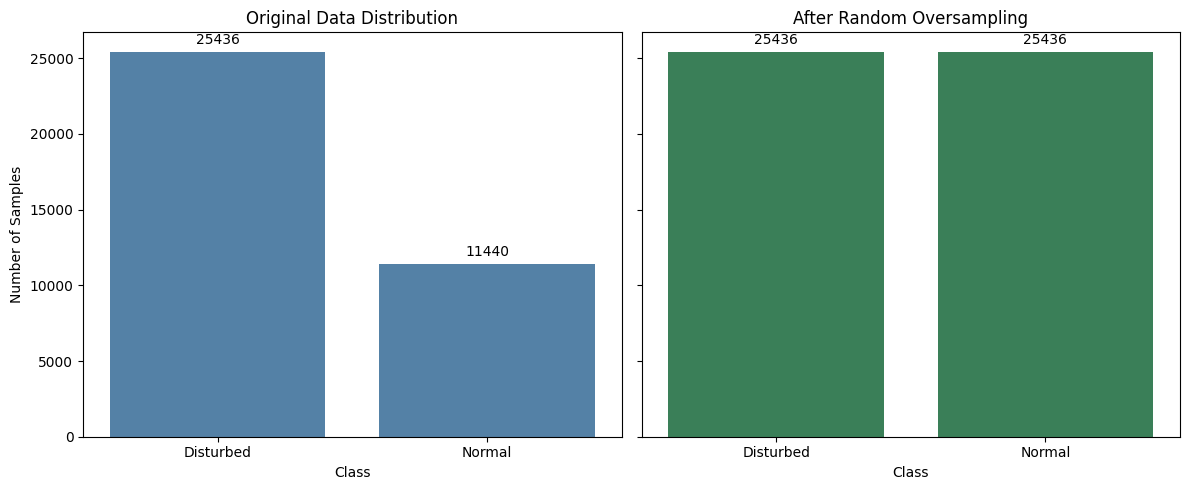

In [100]:
# Distribution after sampling comparison

# Decode encoded labels
original_labels = l_encoder.inverse_transform(
    pd.Series(y_train).astype(int)
)

oversampling_labels = l_encoder.inverse_transform(
    pd.Series(y_train_resampled).astype(int)
)

# Count each class

original_counts = pd.Series(original_labels).value_counts().sort_index()
oversampling_counts = pd.Series(oversampling_labels).value_counts().sort_index()

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

# Original distribution (for reference)
sns.barplot(
    x=original_counts.index.astype(str),
    y=original_counts.values,
    ax=axes[0],
    color="steelblue"
)

axes[0].set_title("Original Data Distribution")
axes[0].set_xlabel("Class")
axes[0].set_ylabel("Number of Samples")

# After oversampling
sns.barplot(
    x=oversampling_counts.index.astype(str),
    y=oversampling_counts.values,
    ax=axes[1],
    color="seagreen"
)

axes[1].set_title("After Random Oversampling")
axes[1].set_xlabel("Class")
axes[1].set_ylabel("Number of Samples")

# Add the counts above each bar
for ax in axes:
    for container in ax.containers:
        ax.bar_label(container, padding=3)

plt.tight_layout()
plt.show()

Logistic Regression Model

In [101]:
labels = l_encoder.classes_ # To be used later

In [102]:
# UNTUNED model
lr_clf = LogisticRegression(random_state= 42) 

# Train the logistic classifier
lr_clf.fit(x_train_resampled, y_train_resampled)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

In [103]:
# Training Classification Report
y_train_lr_pred = lr_clf.predict(x_train_resampled)
print("TRAINING REPORT:")
print(classification_report(y_train_resampled, y_train_lr_pred, target_names=labels)) 

# Testing Classification Report
y_test_lr_pred = lr_clf.predict(X_test_dtm)
print("\nTESTING REPORT:")
print(classification_report(y_test, y_test_lr_pred, target_names=labels)) 

TRAINING REPORT:
              precision    recall  f1-score   support

   Disturbed       1.00      0.98      0.99     25436
      Normal       0.98      1.00      0.99     25436

    accuracy                           0.99     50872
   macro avg       0.99      0.99      0.99     50872
weighted avg       0.99      0.99      0.99     50872


TESTING REPORT:
              precision    recall  f1-score   support

   Disturbed       0.97      0.94      0.96     10901
      Normal       0.88      0.95      0.91      4903

    accuracy                           0.94     15804
   macro avg       0.93      0.94      0.93     15804
weighted avg       0.95      0.94      0.94     15804



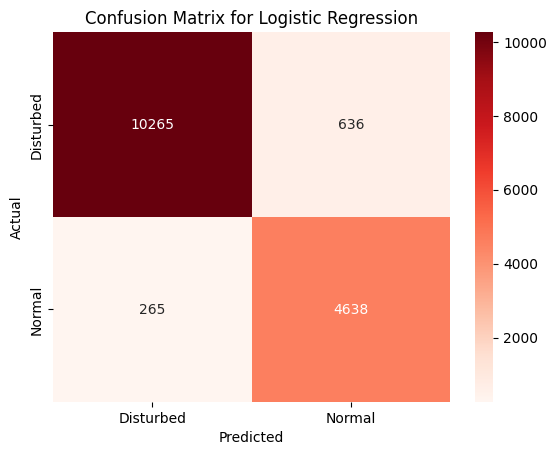

In [104]:
conf_matrix = confusion_matrix(y_test, y_test_lr_pred)
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Reds', xticklabels=labels, yticklabels=labels)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix for Logistic Regression')
plt.show()

Logistic Regression Hyperparameter Tuning

In [105]:
# Pipeline
lr_pipeline = Pipeline([
    (
        "vectorizer",
        CountVectorizer(
            stop_words=None,
            ngram_range=(1, 2),
            max_df=0.7,
            max_features=50_000
        )
    ),
    (
        "oversampler",
        RandomOverSampler(random_state=42)
    ),
    (
        "classifier",
        LogisticRegression(
            random_state=42,
            max_iter=1000
        )
    )
])

In [106]:
# GridSearchCV
lr_parameter_grid = {
    "classifier__C": [0.1, 1.0, 5.0, 10.0],
    "classifier__class_weight": [None, "balanced"],
    "classifier__solver": ["liblinear", "saga"]
}

lr_cv_strategy = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

lr_grid_search = GridSearchCV(
    estimator=lr_pipeline,
    param_grid=lr_parameter_grid,
    scoring="f1_weighted",
    cv=lr_cv_strategy,
    n_jobs=-1,
    verbose=2,
    return_train_score=True
)

In [107]:
# Fit using the original preprocessed text
lr_grid_search.fit(
    x_train,
    y_train
)

print("Complete!\n") # Debug

print("Best parameters:")
print(lr_grid_search.best_params_)

print("\nBest cross-validation weighted F1:")
print(lr_grid_search.best_score_)

# Put best winning pipeline
best_lr_pipeline = lr_grid_search.best_estimator_

Fitting 5 folds for each of 16 candidates, totalling 80 fits
Complete!

Best parameters:
{'classifier__C': 5.0, 'classifier__class_weight': None, 'classifier__solver': 'liblinear'}

Best cross-validation weighted F1:
0.940608317724101


In [108]:
# Test on best LR pipeline
y_test_pred_lr_tuned = best_lr_pipeline.predict(
    x_test
)

Tuned Logistic Regression accuracy:
0.9448873702860036

Classification report (Logistic Regression Tuned):
              precision    recall  f1-score   support

   Disturbed       0.97      0.95      0.96     10901
      Normal       0.89      0.94      0.91      4903

    accuracy                           0.94     15804
   macro avg       0.93      0.94      0.94     15804
weighted avg       0.95      0.94      0.95     15804


Confusion matrix:


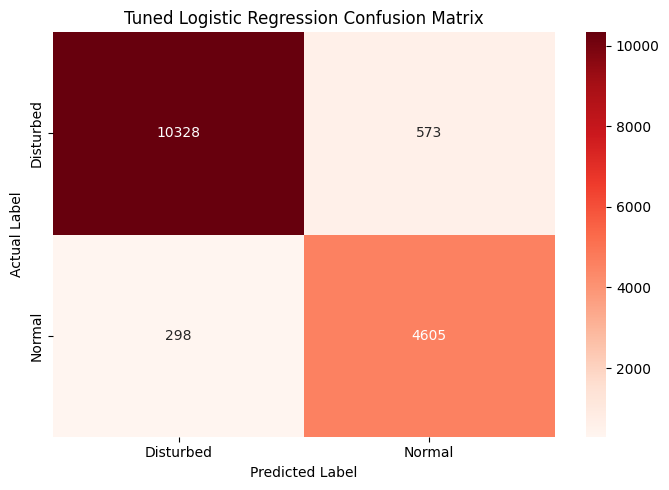

In [109]:
# Reports

lr_tuned_accuracy = accuracy_score(
    y_test,
    y_test_pred_lr_tuned
)

print("Tuned Logistic Regression accuracy:")
print(lr_tuned_accuracy)

print("\nClassification report (Logistic Regression Tuned):")
print(
    classification_report(
        y_test,
        y_test_pred_lr_tuned,
        target_names=l_encoder.classes_
    )
)

print("\nConfusion matrix:")
lr_tuned_cm = confusion_matrix(
    y_test,
    y_test_pred_lr_tuned
)

# Plot heatmap
plt.figure(figsize=(7, 5))

sns.heatmap(
    lr_tuned_cm,
    annot=True,
    fmt="d",
    cmap="Reds",
    xticklabels=labels,
    yticklabels=labels
)

plt.title("Tuned Logistic Regression Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.tight_layout()
plt.show()

Multinomial Naive Bayes Model

In [110]:
nb_clf = MultinomialNB(alpha=0.05)

nb_clf.fit(x_train_resampled, y_train_resampled)

,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",0.05
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None


In [111]:
# Training Classification Report
y_train_cnb_pred = nb_clf.predict(x_train_resampled)
print("TRAINING REPORT:")
print(classification_report(y_train_resampled, y_train_cnb_pred, target_names=labels)) 

# Testing Classification Report
y_test_nb_pred = nb_clf.predict(X_test_dtm)
print("\nTESTING REPORT:")
print(classification_report(y_test, y_test_nb_pred, target_names=labels))

TRAINING REPORT:
              precision    recall  f1-score   support

   Disturbed       0.91      0.97      0.94     25436
      Normal       0.97      0.90      0.93     25436

    accuracy                           0.94     50872
   macro avg       0.94      0.94      0.94     50872
weighted avg       0.94      0.94      0.94     50872


TESTING REPORT:
              precision    recall  f1-score   support

   Disturbed       0.89      0.97      0.93     10901
      Normal       0.91      0.72      0.81      4903

    accuracy                           0.89     15804
   macro avg       0.90      0.85      0.87     15804
weighted avg       0.89      0.89      0.89     15804



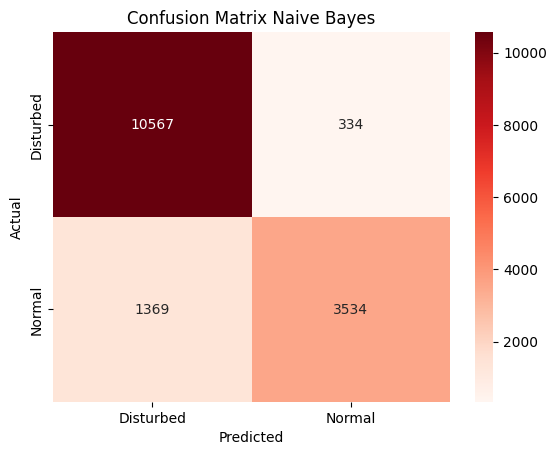

In [112]:
cm = confusion_matrix(y_test, y_test_nb_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', xticklabels=labels, yticklabels=labels)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix Naive Bayes')
plt.show()

MultinomialNB Hyperparameter Tuning

In [113]:
# Pipeline
nb_pipeline = Pipeline([
    (
        "vectorizer",
        CountVectorizer(
            stop_words=None,
            ngram_range=(1, 2),
            max_df=0.7,
            max_features=50_000
        )
    ),
    (
        "oversampler",
        RandomOverSampler(random_state=42)
    ),
    (
        "classifier",
        MultinomialNB()
    )
])

In [114]:
# Parameter Grid

nb_parameter_grid = {
    "classifier__alpha": [
        0.01, 0.1, 0.5, 1.0, 2.0, 5.0
    ],
    "classifier__fit_prior": [
        True, False
    ]
}

nb_cv_strategy = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

nb_grid_search = GridSearchCV(
    estimator=nb_pipeline,
    param_grid=nb_parameter_grid,
    scoring="f1_weighted",
    cv=nb_cv_strategy,
    n_jobs=-1,
    verbose=2,
    return_train_score=True
)

In [115]:
# Train Model
nb_grid_search.fit(
    x_train,
    y_train
)

print("Complete!\n") # Debug

print("Best parameters:")
print(nb_grid_search.best_params_)

print("\nBest cross-validation weighted F1:")
print(nb_grid_search.best_score_)

Fitting 5 folds for each of 12 candidates, totalling 60 fits
Complete!

Best parameters:
{'classifier__alpha': 0.5, 'classifier__fit_prior': True}

Best cross-validation weighted F1:
0.8855015078912267


In [116]:
# Save best pipeline
best_nb_pipeline = nb_grid_search.best_estimator_

# Test pipeline on data
y_test_pred_nb_tuned = best_nb_pipeline.predict(x_test)

Tuned MultinomialNB accuracy:
0.893761073146039

Classification report:
              precision    recall  f1-score   support

   Disturbed       0.90      0.95      0.92     10901
      Normal       0.87      0.78      0.82      4903

    accuracy                           0.89     15804
   macro avg       0.89      0.86      0.87     15804
weighted avg       0.89      0.89      0.89     15804

Confusion Matrix for MultinomialNB:


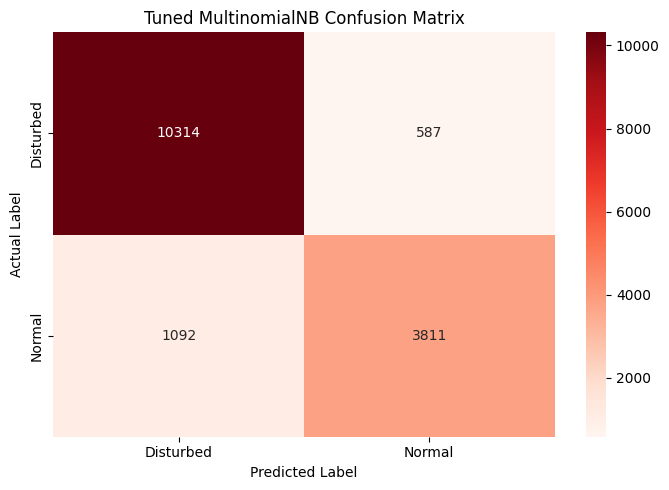

In [117]:
# Report
print("Tuned MultinomialNB accuracy:")
print(accuracy_score(y_test, y_test_pred_nb_tuned))

print("\nClassification report:")
print(classification_report(
    y_test,
    y_test_pred_nb_tuned,
    target_names=l_encoder.classes_
))

print("Confusion Matrix for MultinomialNB:")
plt.figure(figsize=(7, 5))

nb_tuned_cm = confusion_matrix(
    y_test,
    y_test_pred_nb_tuned
)


sns.heatmap(
    nb_tuned_cm,
    annot=True,
    fmt="d",
    cmap="Reds",
    xticklabels=l_encoder.classes_,
    yticklabels=l_encoder.classes_
)

plt.title("Tuned MultinomialNB Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.tight_layout()
plt.show()

Model Comparison

In [118]:
# Training

# Baseline models with manual tuning
y_train_lr_pred = lr_clf.predict(X_train_dtm)
y_train_nb_pred = nb_clf.predict(X_train_dtm)

# Tuned pipelines
y_train_pred_lr_tuned = best_lr_pipeline.predict(x_train)
y_train_pred_nb_tuned = best_nb_pipeline.predict(x_train)

# Testing data already exists

In [119]:
# Collects metrics from training and testing data for both models
def collect_metrics(
    y_train_true,
    y_train_pred,
    y_test_true,
    y_test_pred
):
    train_precision, train_recall, train_f1, _ = (
        precision_recall_fscore_support(
            y_train_true,
            y_train_pred,
            average="weighted",
            zero_division=0
        )
    )

    test_precision, test_recall, test_f1, _ = (
        precision_recall_fscore_support(
            y_test_true,
            y_test_pred,
            average="weighted",
            zero_division=0
        )
    )

    return {
        "Training Accuracy": accuracy_score(
            y_train_true,
            y_train_pred
        ),
        "Test Accuracy": accuracy_score(
            y_test_true,
            y_test_pred
        ),
        "Training Weighted F1": train_f1,
        "Test Weighted F1": test_f1,
        "Test Weighted Precision": test_precision,
        "Train Weighted Precision": train_precision,
        "Test Weighted Recall": test_recall,
        "Train Weighted Recall": train_recall
    }

In [120]:
# Model Comparison
model_comparison = pd.DataFrame(
    [
        collect_metrics(
            y_train,
            y_train_lr_pred,
            y_test,
            y_test_lr_pred
        ),
        collect_metrics(
            y_train,
            y_train_pred_lr_tuned,
            y_test,
            y_test_pred_lr_tuned
        ),
        collect_metrics(
            y_train,
            y_train_nb_pred,
            y_test,
            y_test_nb_pred
        ),
        collect_metrics(
            y_train,
            y_train_pred_nb_tuned,
            y_test,
            y_test_pred_nb_tuned
        )
    ],
    index=[
        "Baseline Logistic Regression",
        "Tuned Logistic Regression",
        "Baseline MultinomialNB",
        "Tuned MultinomialNB"
    ]
)

model_comparison

,Training Accuracy,Test Accuracy,Training Weighted F1,Test Weighted F1,Test Weighted Precision,Train Weighted Precision,Test Weighted Recall,Train Weighted Recall
Baseline Logistic Regression,0.987227,0.942989,0.987292,0.943535,0.945229,0.987672,0.942989,0.987227
Tuned Logistic Regression,0.996203,0.944887,0.996209,0.945287,0.946325,0.996240,0.944887,0.996203
Baseline MultinomialNB,0.946659,0.892242,0.946288,0.888326,0.894099,0.946411,0.892242,0.946659
Tuned MultinomialNB,0.926538,0.893761,0.926492,0.892079,0.892555,0.926451,0.893761,0.926538


App Creation Testing

In [125]:
sample = "I have been feeling exhausted and hopeless lately"

# Apply SAME preprocessing function
processed_statement = preprocess_data(sample)

# Apply SAME vectorizer (c_vectorizer, under the vectorizer section of the notebook)
statement_vector = c_vectorizer.transform(
    [processed_statement]
)

# Predict using the logistic regression model
prediction_encoded = lr_clf.predict(statement_vector)

# Convert the encoded result back to its class name (Normal (1) or Disturbed (0))
prediction_label = l_encoder.inverse_transform(
    prediction_encoded.astype(int)
)

print("Original statement:", sample)
print("Processed statement:", processed_statement)
print("Encoded prediction:", prediction_encoded[0])
print("Predicted class:", prediction_label[0])

Original statement: I have been feeling exhausted and hopeless lately
Processed statement: feel exhaust hopeless late
Encoded prediction: 0
Predicted class: Disturbed


In [ ]:
# Save components

joblib.dump(best_lr_pipeline, "logistic_regression_model.pkl") # Logistic Regression hyperparameter-tuned model was the best one
joblib.dump(l_encoder, "label_encoder.pkl")

print("Components saved!")

Components saved!


In [ ]:
# Small code to check whether files exist

files = [
    "logistic_regression_model.pkl",
    "label_encoder.pkl"
]

for file in files:
    print(file, "exists:", os.path.exists(file))

logistic_regression_model.pkl exists: True
count_vectorizer.pkl exists: True
label_encoder.pkl exists: True
